In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("/kaggle/input/datasets/wisd9gom24/stock-price-4/Stock_Prices.csv")

In [3]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [5]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [6]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [10]:
df["open"] = df["open"].fillna(df["open"].mean())
df["high"] = df["high"].fillna(df["high"].mean())
df["low"] = df["low"].fillna(df["low"].mean())

In [11]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [13]:
df["open"] = df["open"].fillna(df["open"].mean())
df["high"] = df["high"].fillna(df["high"].mean())
df["low"] = df["low"].fillna(df["low"].mean())

In [14]:
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

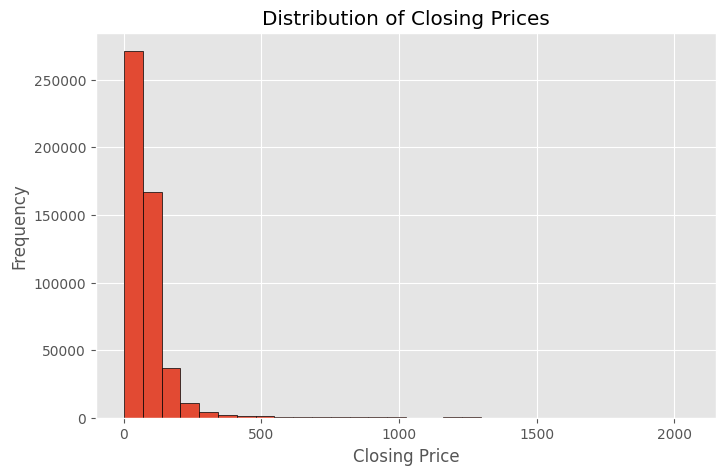

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["close"], bins=30, edgecolor="black")
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

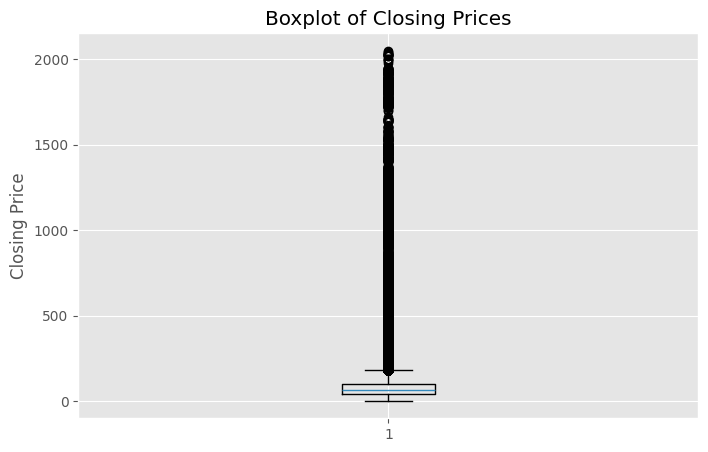

In [16]:
plt.figure(figsize=(8,5))
plt.boxplot(df["close"])
plt.title("Boxplot of Closing Prices")
plt.ylabel("Closing Price")
plt.show()

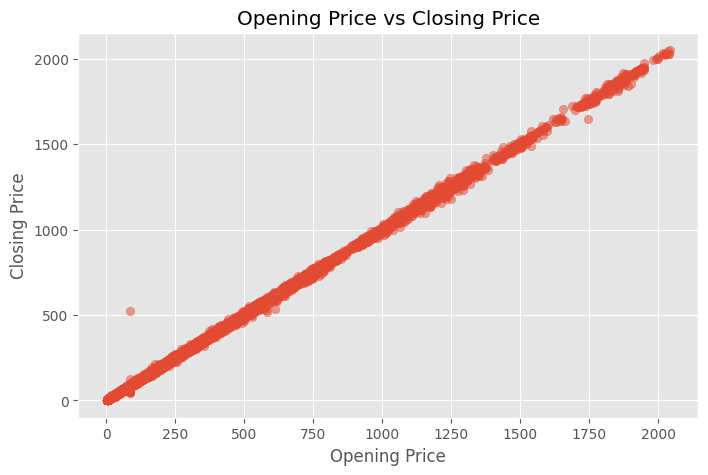

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["open"], df["close"], alpha=0.5)
plt.title("Opening Price vs Closing Price")
plt.xlabel("Opening Price")
plt.ylabel("Closing Price")
plt.show()

In [18]:
correlation = df[["open", "high", "low", "close", "volume"]].corr()
correlation

,open,high,low,close,volume
open,1.000000,0.999941,0.999927,0.999856,-0.148724
high,0.999941,1.000000,0.999905,0.999918,-0.148344
low,0.999927,0.999905,1.000000,0.999922,-0.149284
close,0.999856,0.999918,0.999922,1.000000,-0.148839
volume,-0.148724,-0.148344,-0.149284,-0.148839,1.000000


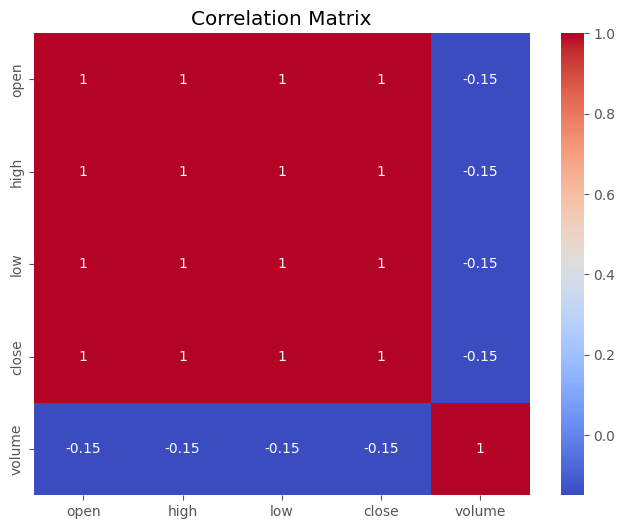

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Conclusion

## Key Findings

- The dataset contains stock price information, including opening, high, low, closing prices, and trading volume.
- Missing values in the Open, High, and Low columns were handled using mean imputation.
- The histogram showed the distribution of stock closing prices.
- The boxplot helped identify potential outliers in the closing prices.
- The scatter plot revealed a strong positive relationship between opening and closing prices.
- The correlation matrix indicated that Open, High, Low, and Close prices are highly correlated, while Volume has a weaker relationship with the price variables.

## Conclusion

The exploratory data analysis provided valuable insights into the stock price dataset. The strong correlations among price variables suggest consistent market movements, while the visualizations helped identify patterns and potential outliers. This analysis serves as a foundation for further predictive modeling and time series analysis.

# Exploratory Data Analysis of Stock Prices

## Codveda Data Analytics Internship – Level 1 Task 2

**Prepared by:** Wisdom Osayande Osamudiamen

**Tools Used:** Python, Pandas, Matplotlib, Seaborn

**Dataset:** Stock Prices Dataset

## 1. Import Libraries

## 2. Load the Dataset

## 3. Explore the Dataset

## 4. Handle Missing Values

## 5. Summary Statistics

## 6. Histogram of Closing Prices

## 7. Boxplot of Closing Prices

## 8. Scatter Plot: Open vs Close Prices

## 9. Correlation Analysis

## 10. Conclusion

# Thank You

Thank you for reviewing this project.

This notebook was completed as part of the **Codveda Data Analytics Internship – Level 1 Task 2: Exploratory Data Analysis**.

**Prepared by:** Wisdom Osayande Osamudiamen